In [1]:
import os
os.chdir("../")

from dotenv import load_dotenv
load_dotenv()
os.environ["WANDB_API_KEY"] = os.getenv("WANDB_API_KEY")

### Delete all local experiments:

In [2]:
if False: # SET TO TRUE TO DELETE ALL LOCAL DBs
    from ppm.wandb_utils import list_local_experiments, delete_experiment_data
    for exp in list_local_experiments():
        delete_experiment_data(exp)

In [2]:
import os, sys, importlib

print("cwd:", os.getcwd())
print("python:", sys.executable)
print("first sys.path entries:", sys.path[:8])

import visualization
print("visualization type:", type(visualization))
print("visualization file:", getattr(visualization, "__file__", None))
print("visualization spec:", visualization.__spec__)
print("search locations:", getattr(visualization.__spec__, "submodule_search_locations", None))

importlib.invalidate_caches()


cwd: /app
python: /usr/bin/python
first sys.path entries: ['/app/nanoGPT', '/app/visualization', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages']
visualization type: <class 'module'>
visualization file: /app/visualization/visualization.py
visualization spec: ModuleSpec(name='visualization', loader=<_frozen_importlib_external.SourceFileLoader object at 0xebba34384d10>, origin='/app/visualization/visualization.py')
search locations: None


## Start of Code

In [3]:
from ppm.wandb_utils import load_multiple_experiments, BASELINE_PROJECT
from visualization import (
    plot_bar, plot_learning_curves, plot_grouped_bars,
    plot_correlation_bars, plot_3d_manifold, plot_split_curves,
    plot_combined_curves, plot_dataset_curves, save_figure, PlotConfig, alias, _apply_style
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
%%capture

PROJECTS = ["exp_001", "exp_002", "exp_003", "exp_004", "exp_005"]
runs, history = load_multiple_experiments(PROJECTS, force_update=False)

baseline_runs, _ = load_multiple_experiments([BASELINE_PROJECT], force_update=False)
baseline_latest = baseline_runs.sort_values("created_at", ascending=False).drop_duplicates("log", keep="first")
baseline_acc = baseline_latest.set_index("log")["best_test_final_next_activity_acc"].to_dict()

In [12]:
runs.columns

Index(['id', 'name', 'r', 'lr', 'log', 'device', 'epochs', 'compile',
       'backbone', 'n_layers', 'patience', 'rnn_type', 'strategy', 'val_size',
       'grad_clip', 'lifecycle', 'precision', 'val_split', 'batch_size',
       'lora_alpha', 'fine_tuning', 'hidden_size', 'num_workers',
       'total_params', 'weight_decay', 'freeze_layers', 'embedding_size',
       'trainable_params', 'continuous_targets', 'categorical_targets',
       'continuous_features', 'categorical_features', 'memory_safety_margin',
       'time_positional_encoding', 'duration_sec',
       'best_test_final_next_activity_acc',
       'best_test_final_next_activity_loss', 'dataset/filtered_dataset_cases',
       'dataset/filtered_dataset_end', 'dataset/filtered_dataset_events',
       'dataset/filtered_dataset_max_duration_days',
       'dataset/filtered_dataset_start', 'dataset/orig_dataset_cases',
       'dataset/orig_dataset_end', 'dataset/orig_dataset_events',
       'dataset/orig_dataset_max_duration_days', '

In [16]:
import pandas as pd

runs2 = runs.copy()

# Make sure both are numeric
runs2['trainable_params'] = pd.to_numeric(runs2['trainable_params'], errors='coerce')
runs2['embedding_size'] = pd.to_numeric(runs2['embedding_size'], errors='coerce')

# ratio
runs2['params_per_dim'] = runs2['trainable_params'] / runs2['embedding_size']

summary = runs2.groupby(['backbone', 'log', 'embedding_size'], as_index=False).agg(
    value=('trainable_params', 'first'),
    value_per_dim=('params_per_dim', 'first')
)

summary


,backbone,log,embedding_size,value,value_per_dim
0,gpt2,BPI12,768.0,14247207,18551.050781
1,gpt2,BPI15,768.0,14665271,19095.404948
2,gpt2,BPI17,768.0,14285632,18601.083333
3,gpt2,BPI19,768.0,14253355,18559.055990
4,gpt2,BPI20PrepaidTravelCosts,768.0,14236448,18537.041667
5,gpt2,BPI20RequestForPayment,768.0,14216467,18511.024740
6,gpt2,BPI20TravelPermitData,768.0,14268725,18579.069010
7,gpt2-large,BPI12,1280.0,39473959,30839.030469
8,gpt2-large,BPI17,1280.0,39537984,30889.050000
9,gpt2-medium,BPI12,1024.0,25287719,24695.038086


In [18]:
PROJECTS = ["BPI12_lrz_001", "BPI17_lrz_001"]
runs_lrz, history = load_multiple_experiments(PROJECTS, force_update=False)

baseline_runs, _ = load_multiple_experiments([BASELINE_PROJECT], force_update=False)
baseline_latest = baseline_runs.sort_values("created_at", ascending=False).drop_duplicates("log", keep="first")
baseline_acc = baseline_latest.set_index("log")["best_test_final_next_activity_acc"].to_dict()

Fetched 77 runs and 3657 history entries to /app/metrics/BPI12_lrz_001.db
Fetched 28 runs and 820 history entries to /app/metrics/BPI17_lrz_001.db
Loaded 105 runs from 2 experiments
Datasets: ['BPI12', 'BPI17']
Database already exists: /app/metrics/baseline-nep.db
Use force_update=True to re-fetch from wandb
Loaded 15 runs from 1 experiments
Datasets: ['BPI12', 'BPI15', 'BPI17', 'BPI19', 'BPI20PrepaidTravelCosts', 'BPI20TravelPermitData', 'BPI20RequestForPayment']


In [23]:
#print(runs_lrz.head())
print(runs_lrz.columns)

Index(['id', 'name', 'r', 'lr', 'log', 'device', 'epochs', 'compile',
       'backbone', 'n_layers', 'patience', 'rnn_type', 'strategy', 'val_size',
       'grad_clip', 'lifecycle', 'min_delta', 'precision', 'val_split',
       'batch_size', 'lora_alpha', 'fine_tuning', 'num_workers',
       'total_params', 'weight_decay', 'freeze_layers', 'trainable_params',
       'continuous_targets', 'categorical_targets', 'continuous_features',
       'categorical_features', 'memory_safety_margin',
       'time_positional_encoding', 'duration_sec', 'best_test_final_loss',
       'best_test_final_next_activity_acc',
       'best_test_final_next_activity_auroc',
       'best_test_final_next_activity_f1',
       'best_test_final_next_activity_loss', 'dataset/filtered_dataset_cases',
       'dataset/filtered_dataset_end', 'dataset/filtered_dataset_events',
       'dataset/filtered_dataset_max_duration_days',
       'dataset/filtered_dataset_start', 'dataset/orig_dataset_cases',
       'dataset/orig_da

In [19]:
import pandas as pd

runs2 = runs_lrz.copy()

# Make sure both are numeric
runs2['trainable_params'] = pd.to_numeric(runs2['trainable_params'], errors='coerce')
runs2['embedding_size'] = pd.to_numeric(runs2['embedding_size'], errors='coerce')

# ratio
runs2['params_per_dim'] = runs2['trainable_params'] / runs2['embedding_size']

summary = runs2.groupby(['backbone', 'log', 'embedding_size'], as_index=False).agg(
    value=('trainable_params', 'first'),
    value_per_dim=('params_per_dim', 'first')
)

summary

KeyError: 'embedding_size'

## Dataset Statistics

In [5]:
dataset_cols = [c for c in runs.columns if c.startswith("dataset/")]
if dataset_cols:
    df_stats = runs[["log"] + dataset_cols].drop_duplicates(subset=["log"]).copy()
    df_stats.columns = [c.replace("dataset/", "") for c in df_stats.columns]
    df_stats = df_stats.rename(columns={"log": "Dataset"}).set_index("Dataset")
    
    summary_rows = []
    for name in df_stats.index:
        row = df_stats.loc[name]
        total_c = int(row["filtered_dataset_cases"])
        total_e = int(row["filtered_dataset_events"])
        summary_rows.append({
            "Dataset": name,
            "Train Cases": int(row["train_cases"]),
            "Train Events": int(row["train_events"]),
            "Test Cases": int(row["test_cases"]),
            "Test Events": int(row["test_events"]),
            "Total Cases": total_c,
            "Total Events": total_e,
            "Avg Events/Case": round(total_e / total_c, 1),
        })
    
    df_summary = pd.DataFrame(summary_rows).set_index("Dataset")
    display(df_summary)
else:
    print("No dataset statistics found in wandb runs. Re-fetch with force_update=True if needed.")

,Train Cases,Train Events,Test Cases,Test Events,Total Cases,Total Events,Avg Events/Case
Dataset,,,,,,,
BPI17,21829,790362,7173,222215,29306,1100691,37.6
BPI20PrepaidTravelCosts,1406,11156,417,3309,1791,15730,8.8
BPI20TravelPermitData,5437,58952,2199,18008,6847,83620,12.2
BPI20RequestForPayment,4184,21643,1218,6201,5701,30153,5.3
BPI15,3406,144376,915,40422,4411,201196,45.6
BPI19,123526,612834,62624,231080,156072,914906,5.9


## Run Counts by Dataset and Backbone

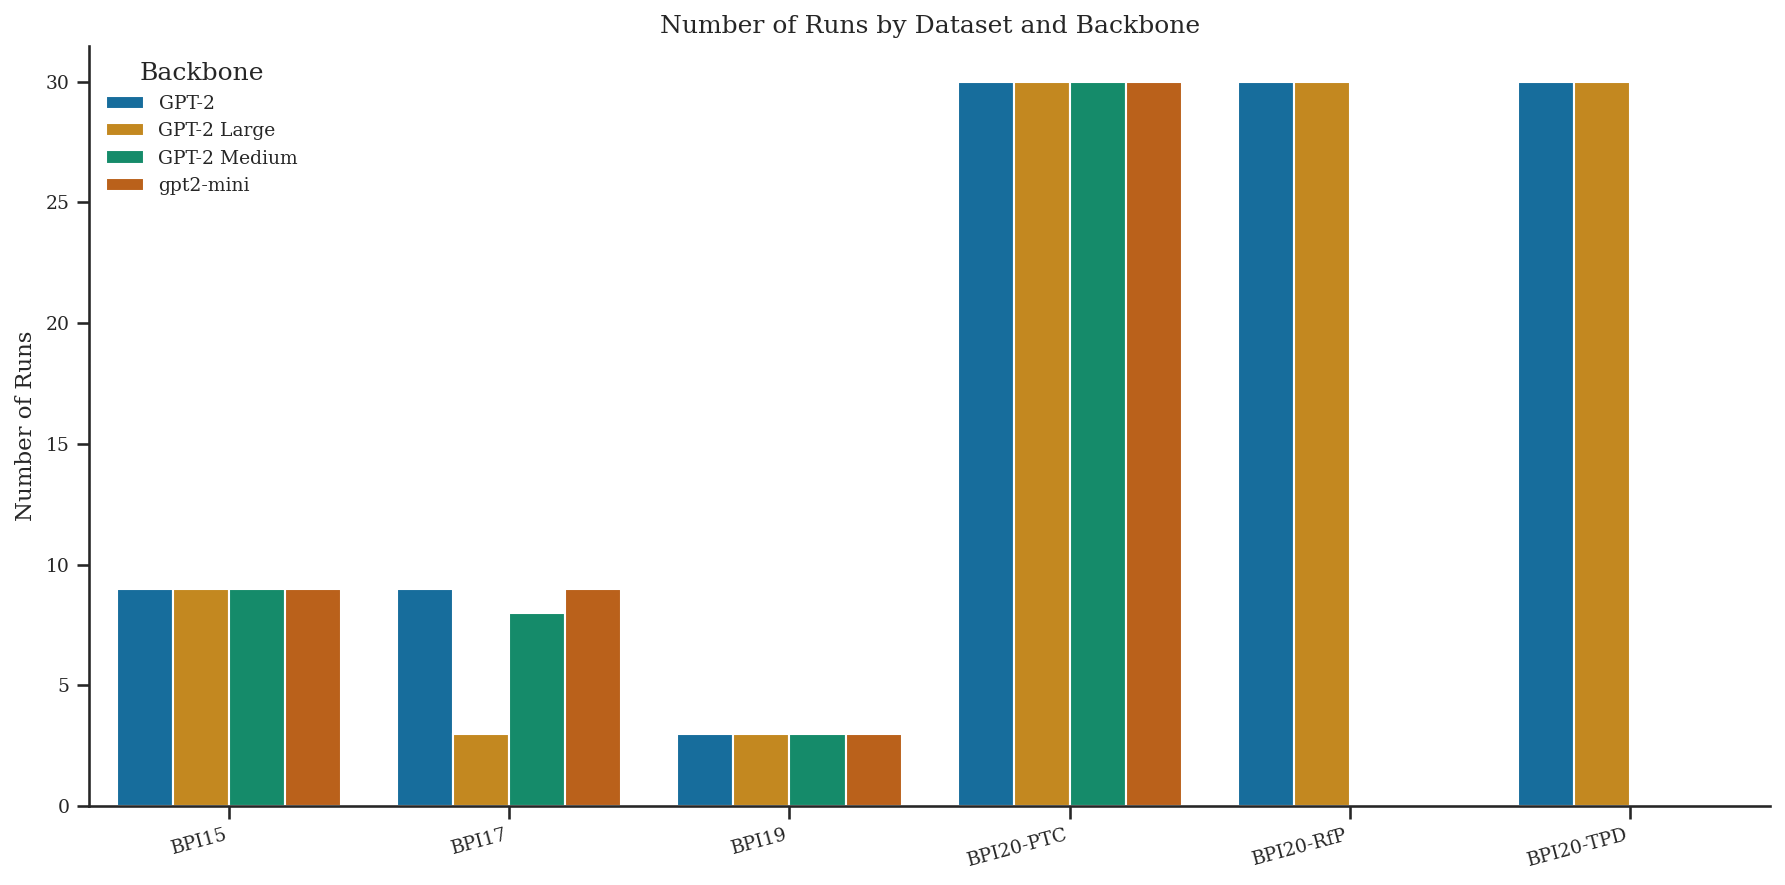

In [6]:
_apply_style()

run_counts = runs.groupby(["log", "backbone"]).size().reset_index(name="count")
run_counts["Dataset"] = run_counts["log"].apply(alias)
run_counts["Backbone"] = run_counts["backbone"].apply(alias)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=run_counts, x="Dataset", y="count", hue="Backbone", ax=ax, palette="colorblind")
ax.set_ylabel("Number of Runs")
ax.set_xlabel("")
ax.set_title("Number of Runs by Dataset and Backbone")
ax.legend(title="Backbone", frameon=False)
ax.tick_params(axis="x", rotation=15)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
fig.tight_layout()
plt.show()

## Accuracy by Learning Rate

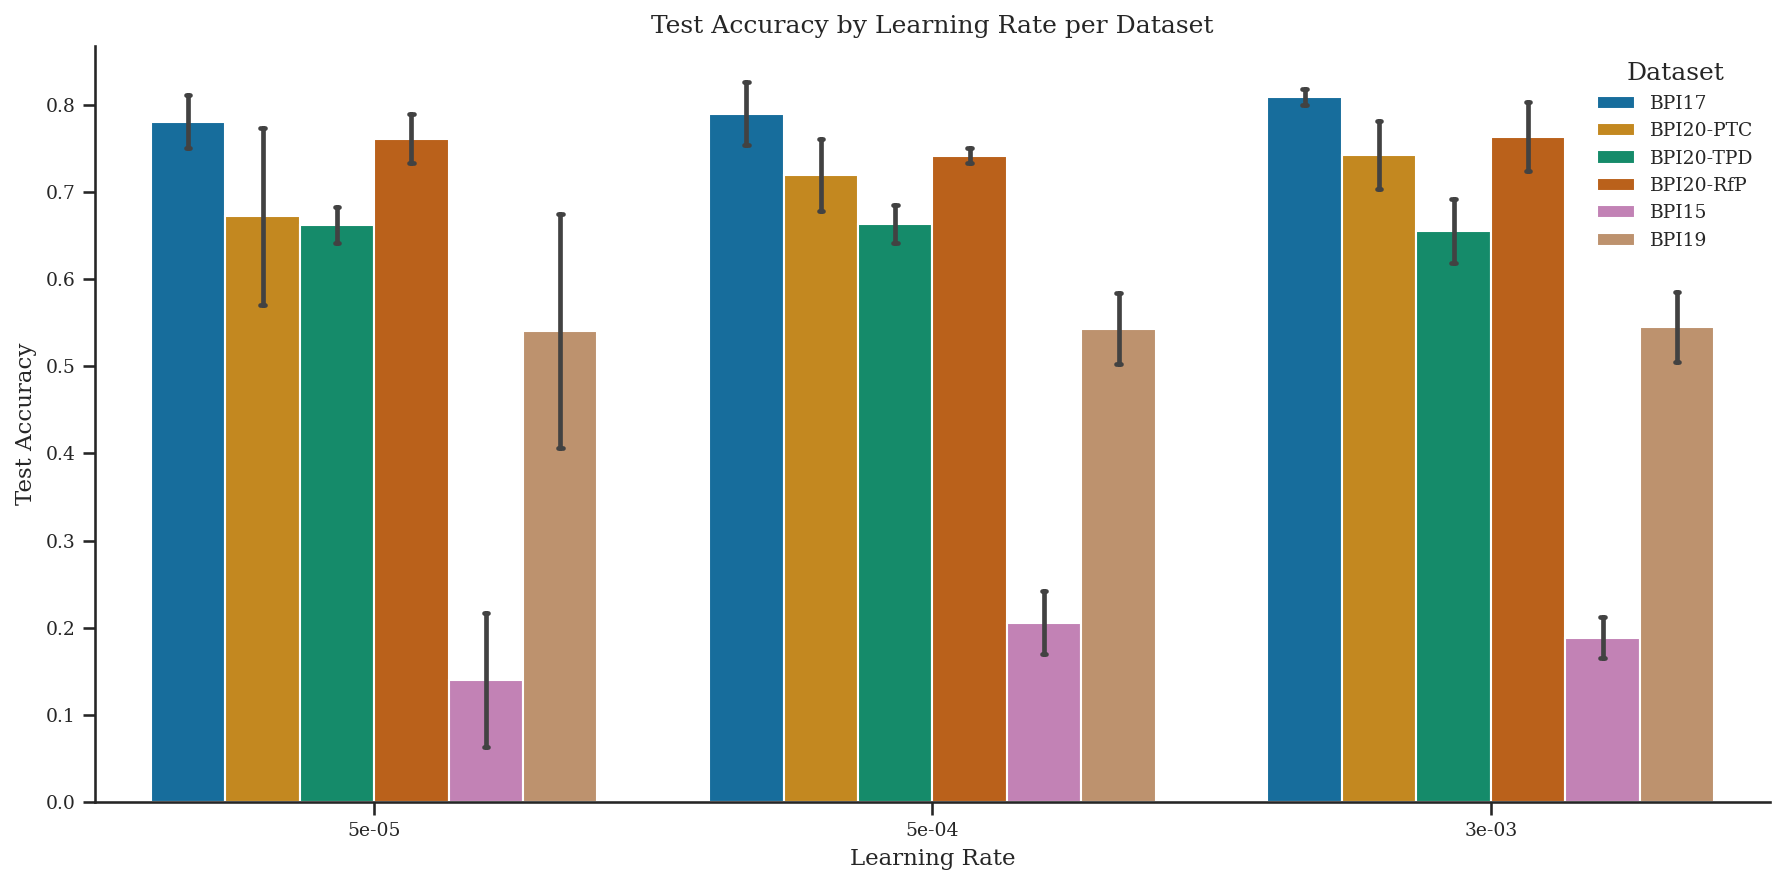

In [7]:
runs["lr_str"] = runs["lr"].apply(lambda x: f"{x:.0e}")

fig = plot_grouped_bars(
    runs,
    y="best_test_final_next_activity_acc",
    x="lr_str",
    hue="log",
    config=PlotConfig(
        figsize=(12, 6),
        title="Test Accuracy by Learning Rate per Dataset",
        xlabel="Learning Rate",
        ylabel="Test Accuracy",
        legend_title="Dataset",
    )
)

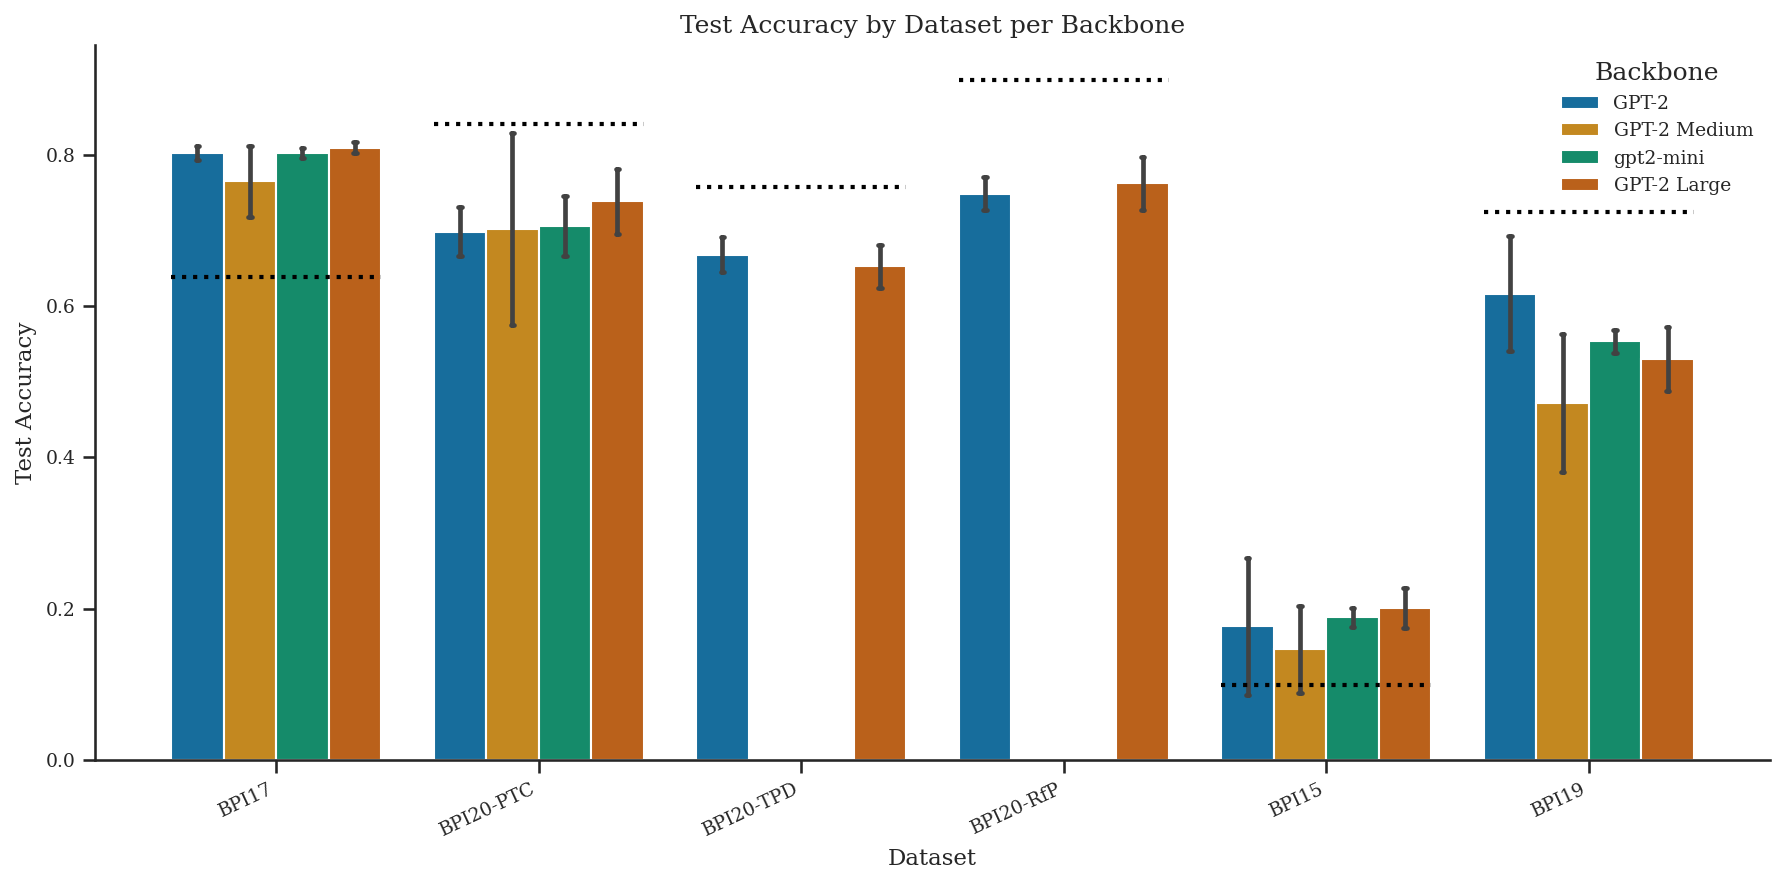

In [8]:
fig2 = plot_grouped_bars(
    runs,
    y="best_test_final_next_activity_acc",
    x="log",
    hue="backbone",
    config=PlotConfig(
        figsize=(12, 6),
        title="Test Accuracy by Dataset per Backbone",
        xlabel="Dataset",
        ylabel="Test Accuracy",
        legend_title="Backbone",
        xtick_rotation=25,
    ),
    baseline=baseline_acc,
)

## Single Run Learning Curves

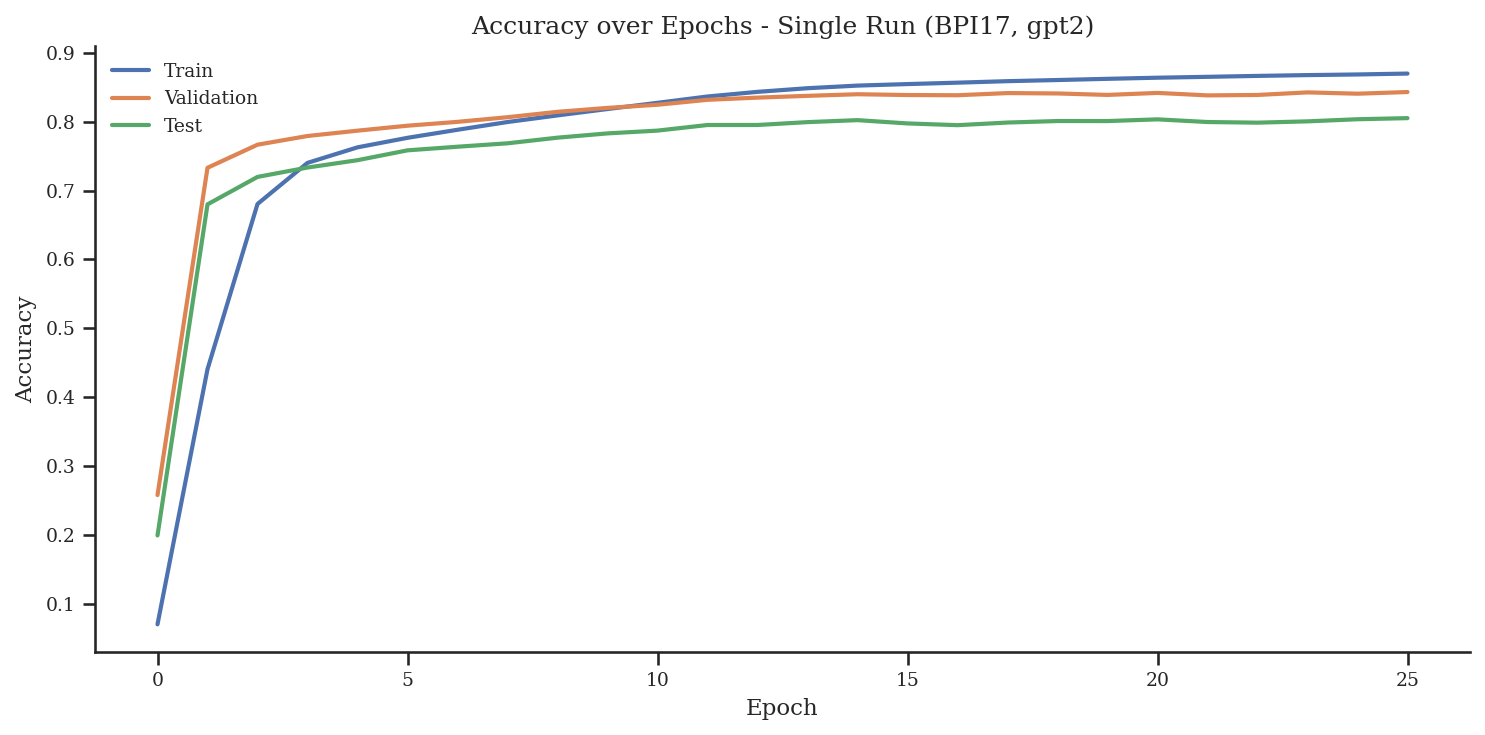

In [9]:
_apply_style()

sample_run = runs.iloc[0]
sample_run_id = sample_run["id"]
sample_history = history[history["run_id"] == sample_run_id].sort_values("step")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_history["step"], sample_history["train_next_activity_acc"], label="Train", linewidth=2)
ax.plot(sample_history["step"], sample_history["val_next_activity_acc"], label="Validation", linewidth=2)
ax.plot(sample_history["step"], sample_history["test_next_activity_acc"], label="Test", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title(f"Accuracy over Epochs - Single Run ({alias(sample_run['log'])}, {sample_run['backbone']})")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

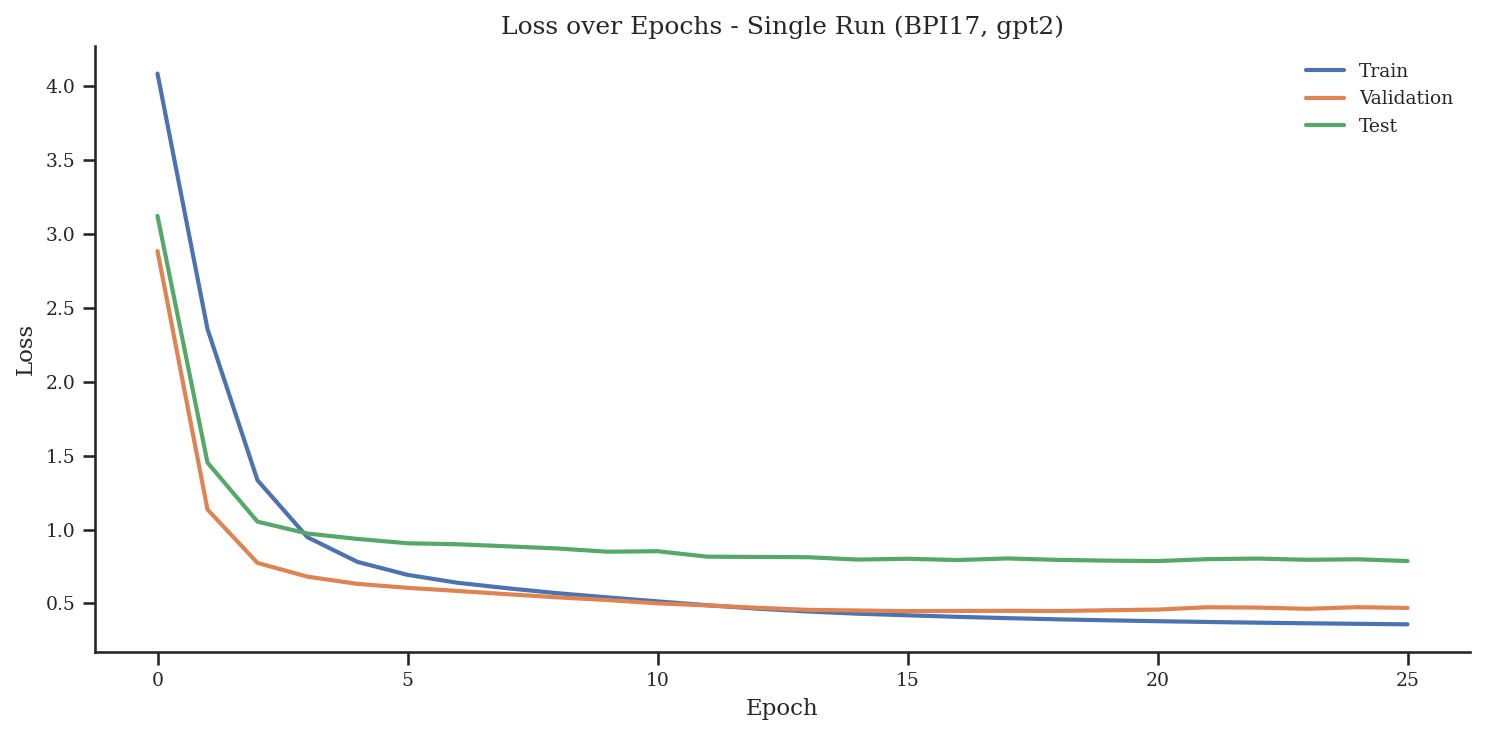

In [10]:
_apply_style()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sample_history["step"], sample_history["train_next_activity_loss"], label="Train", linewidth=2)
ax.plot(sample_history["step"], sample_history["val_next_activity_loss"], label="Validation", linewidth=2)
ax.plot(sample_history["step"], sample_history["test_next_activity_loss"], label="Test", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Loss over Epochs - Single Run ({alias(sample_run['log'])}, {sample_run['backbone']})")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Multi-Run Learning Curves Grid (Identical Parameters)

Selected 6 runs


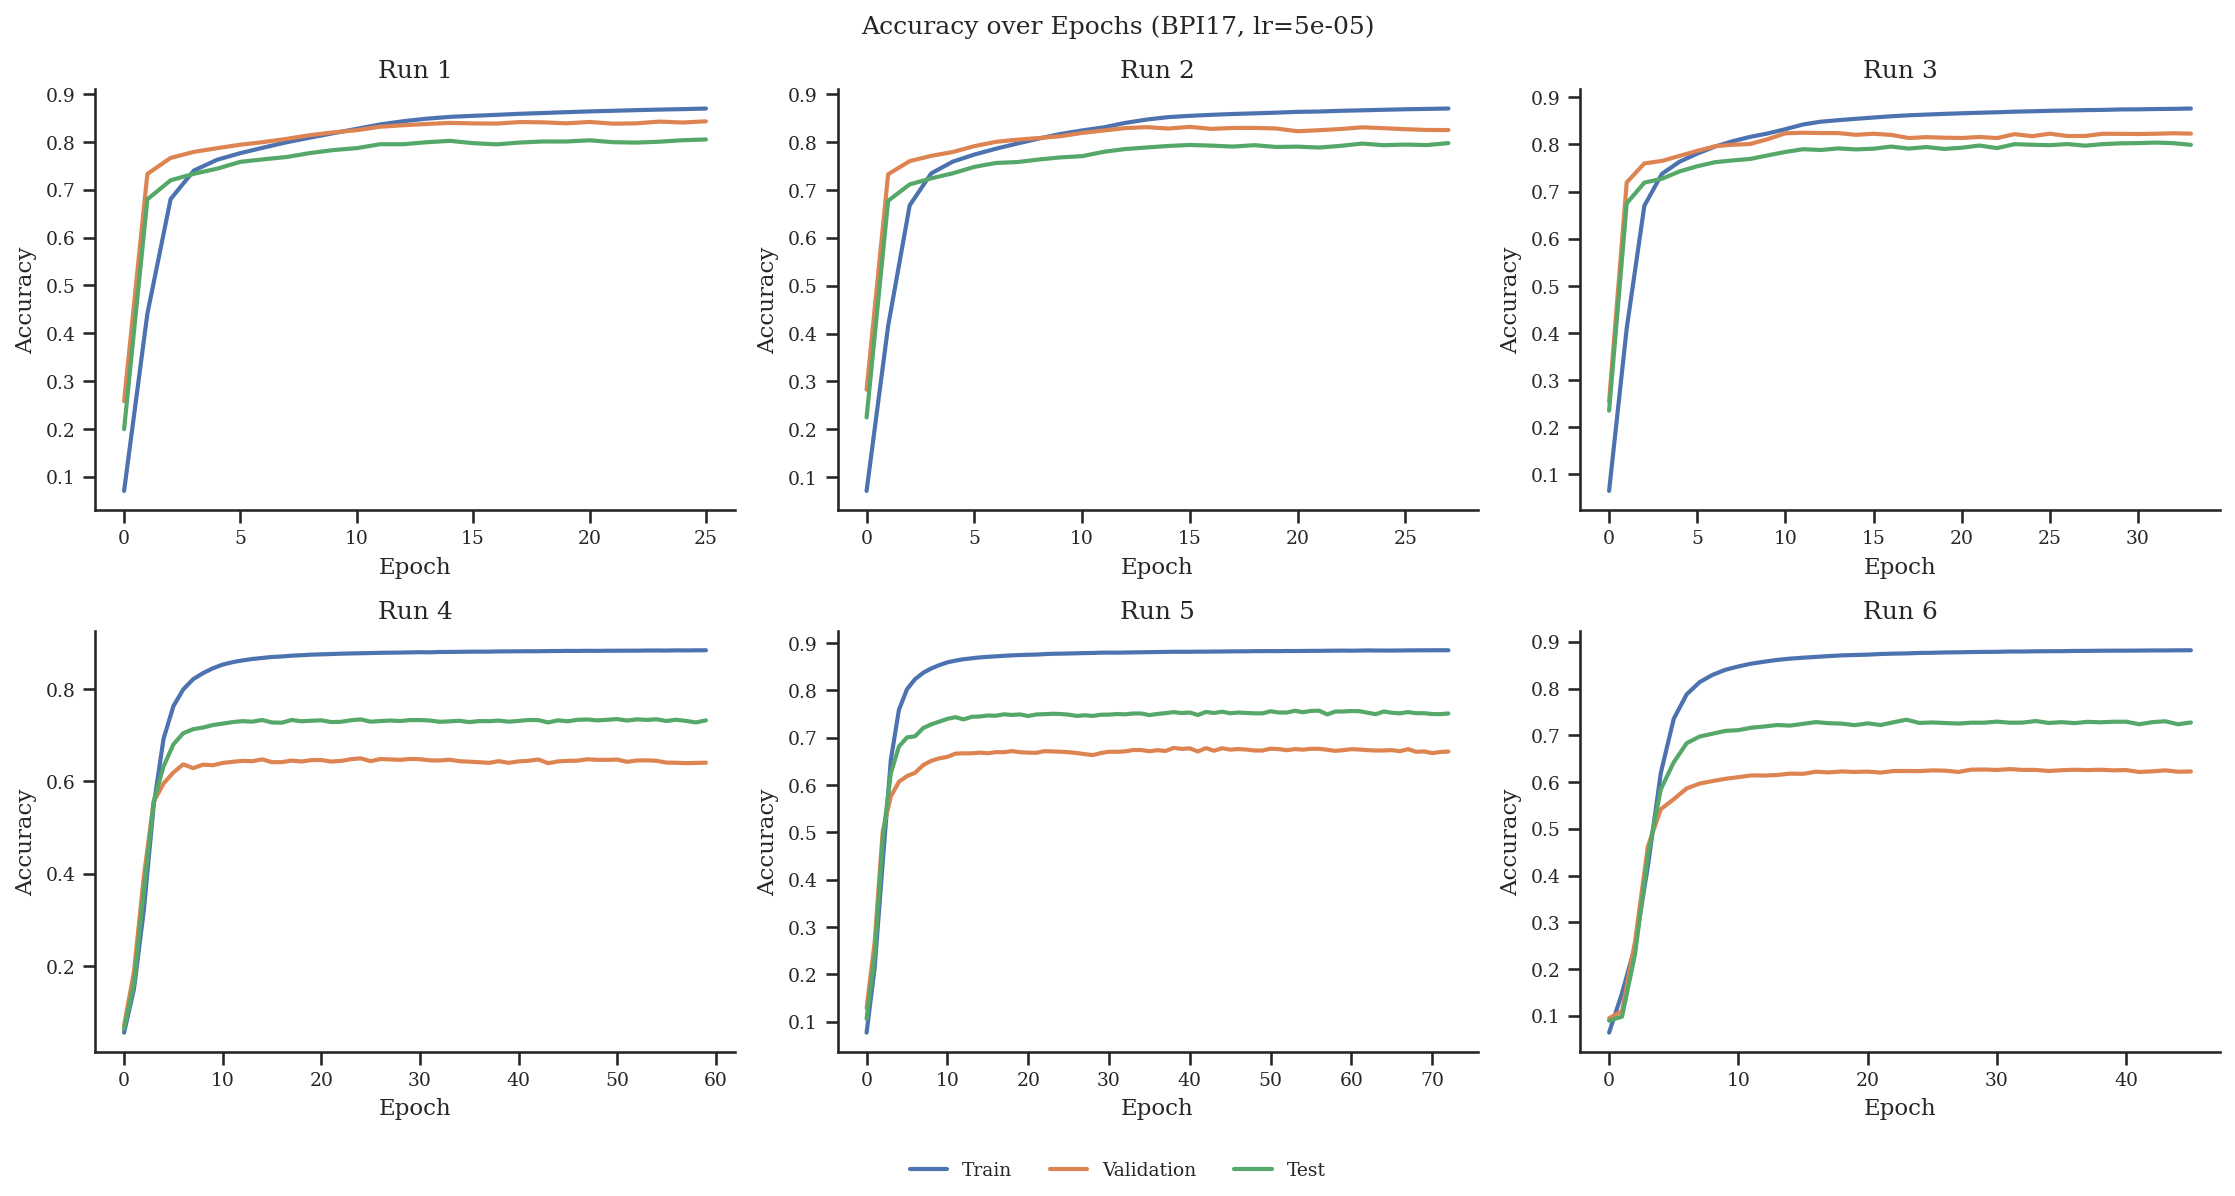

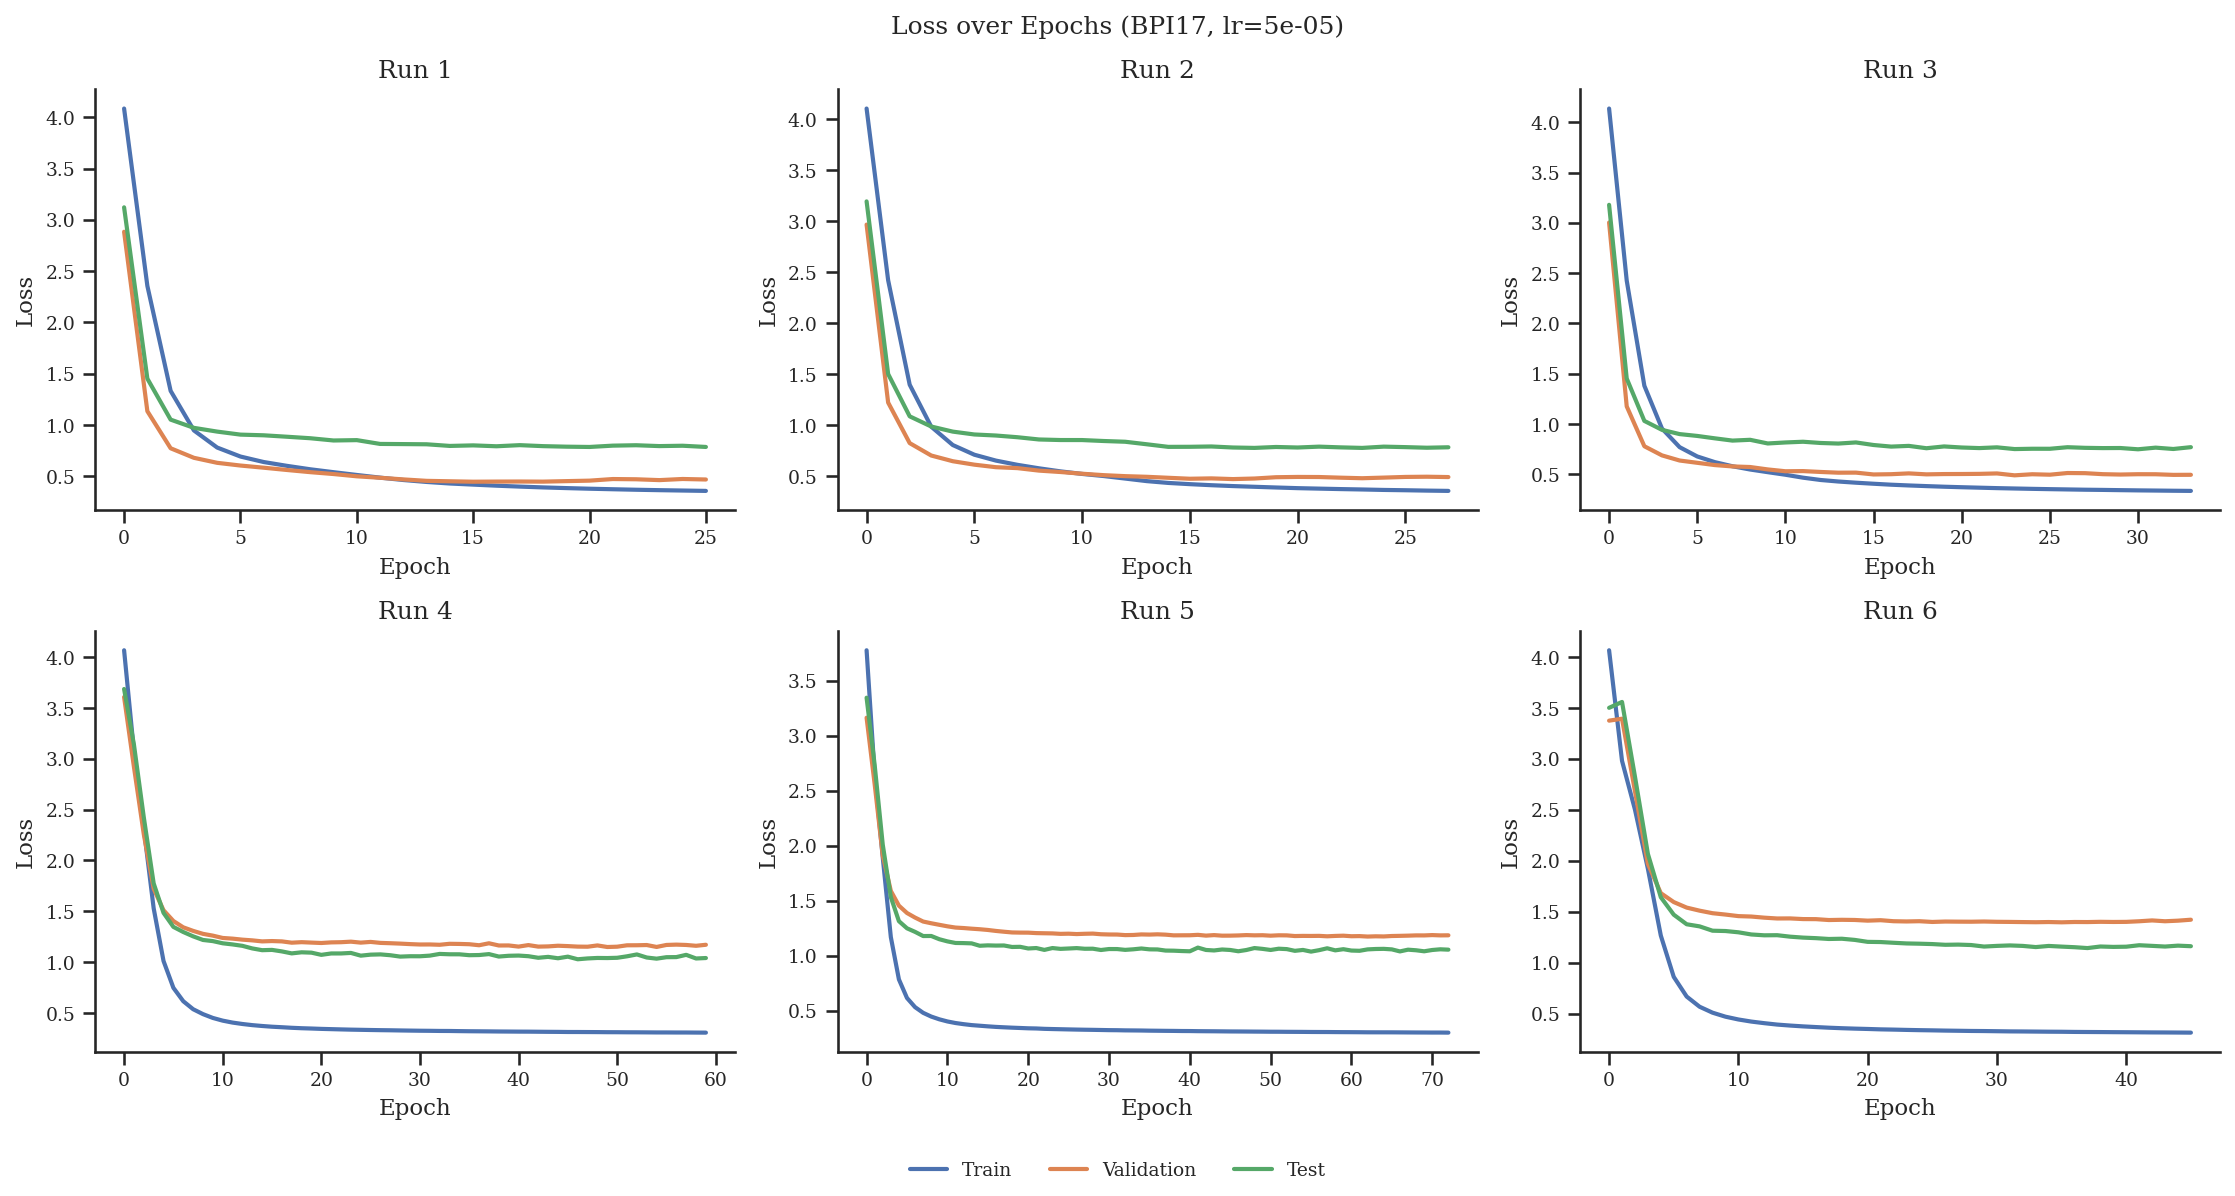

In [11]:
GRID_DATASET = "BPI17"
GRID_LR = 0.00005
GRID_BATCH_SIZE = 256
GRID_SHAPE = (2, 3)

matching_runs = runs[(runs["log"] == GRID_DATASET) & (runs["lr"] == GRID_LR) & (runs["batch_size"] == GRID_BATCH_SIZE)]
matching_runs = matching_runs.head(GRID_SHAPE[0] * GRID_SHAPE[1])
print(f"Selected {len(matching_runs)} runs")

for metric_type, ylabel, cols in [
    ("Accuracy", "Accuracy", ["train_next_activity_acc", "val_next_activity_acc", "test_next_activity_acc"]),
    ("Loss", "Loss", ["train_next_activity_loss", "val_next_activity_loss", "test_next_activity_loss"]),
]:
    _apply_style()
    fig, axes = plt.subplots(GRID_SHAPE[0], GRID_SHAPE[1], figsize=(5 * GRID_SHAPE[1], 4 * GRID_SHAPE[0]))
    axes = axes.flatten()

    for idx, (_, run_row) in enumerate(matching_runs.iterrows()):
        run_hist = history[history["run_id"] == run_row["id"]].sort_values("step")
        ax = axes[idx]
        l1, = ax.plot(run_hist["step"], run_hist[cols[0]], label="Train", linewidth=2)
        l2, = ax.plot(run_hist["step"], run_hist[cols[1]], label="Validation", linewidth=2)
        l3, = ax.plot(run_hist["step"], run_hist[cols[2]], label="Test", linewidth=2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Run {idx + 1}")

    for idx in range(len(matching_runs), len(axes)):
        axes[idx].set_visible(False)

    fig.legend([l1, l2, l3], ["Train", "Validation", "Test"], loc="lower center", ncol=3, fontsize=9, frameon=False)
    fig.suptitle(f"{metric_type} over Epochs ({alias(GRID_DATASET)}, lr={GRID_LR})", fontsize=12)
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()

## Per-Dataset Learning Curves

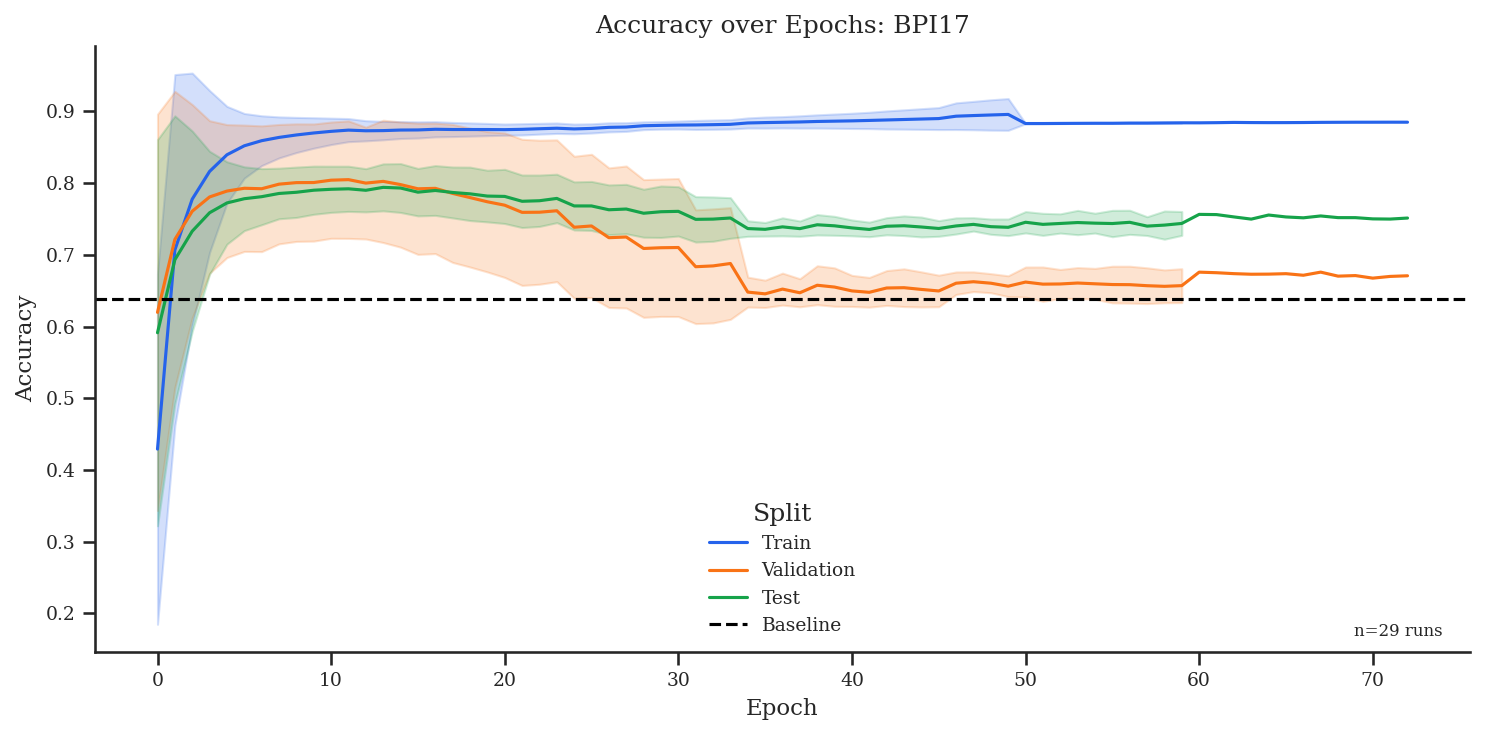

In [12]:
acc_metrics = {
    "train_next_activity_acc": "Train",
    "val_next_activity_acc": "Validation",
    "test_next_activity_acc": "Test",
}

dataset = "BPI17"
baseline_val = baseline_acc.get(dataset)

fig = plot_dataset_curves(
    runs,
    history,
    dataset=dataset,
    metrics=acc_metrics,
    baseline=baseline_val,
    config=PlotConfig(
        figsize=(10, 5),
        title=f"Accuracy over Epochs: {alias(dataset)}",
        xlabel="Epoch",
        ylabel="Accuracy",
        legend_title="Split",
    ),
)
plt.show()

## Train/Val/Test Correlation

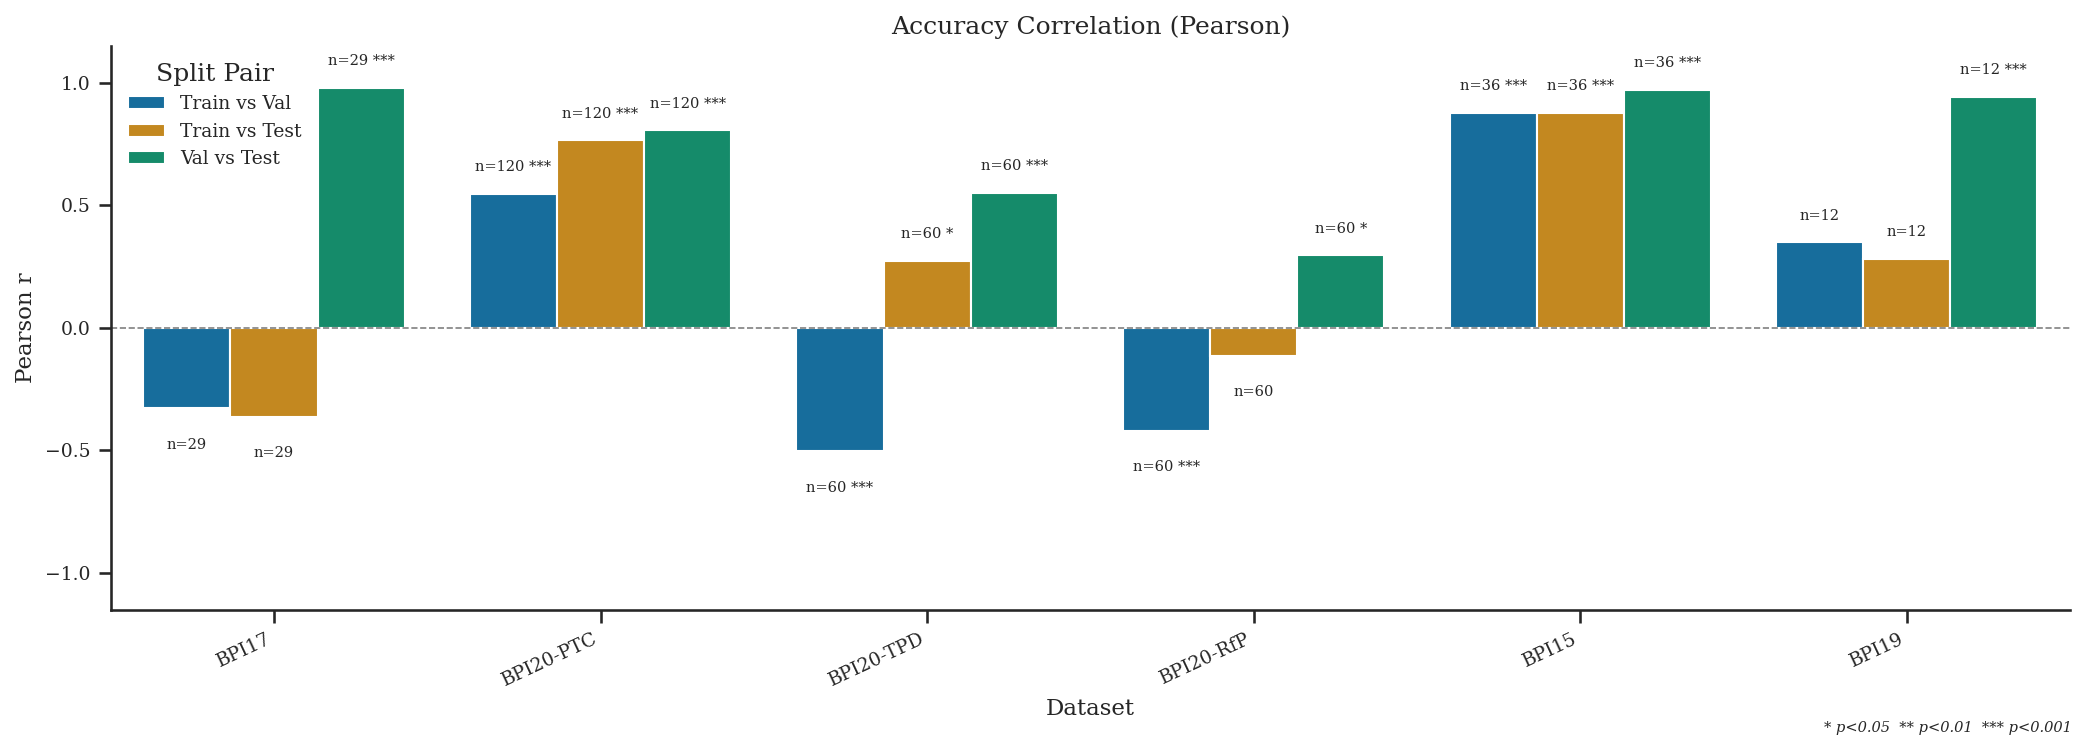

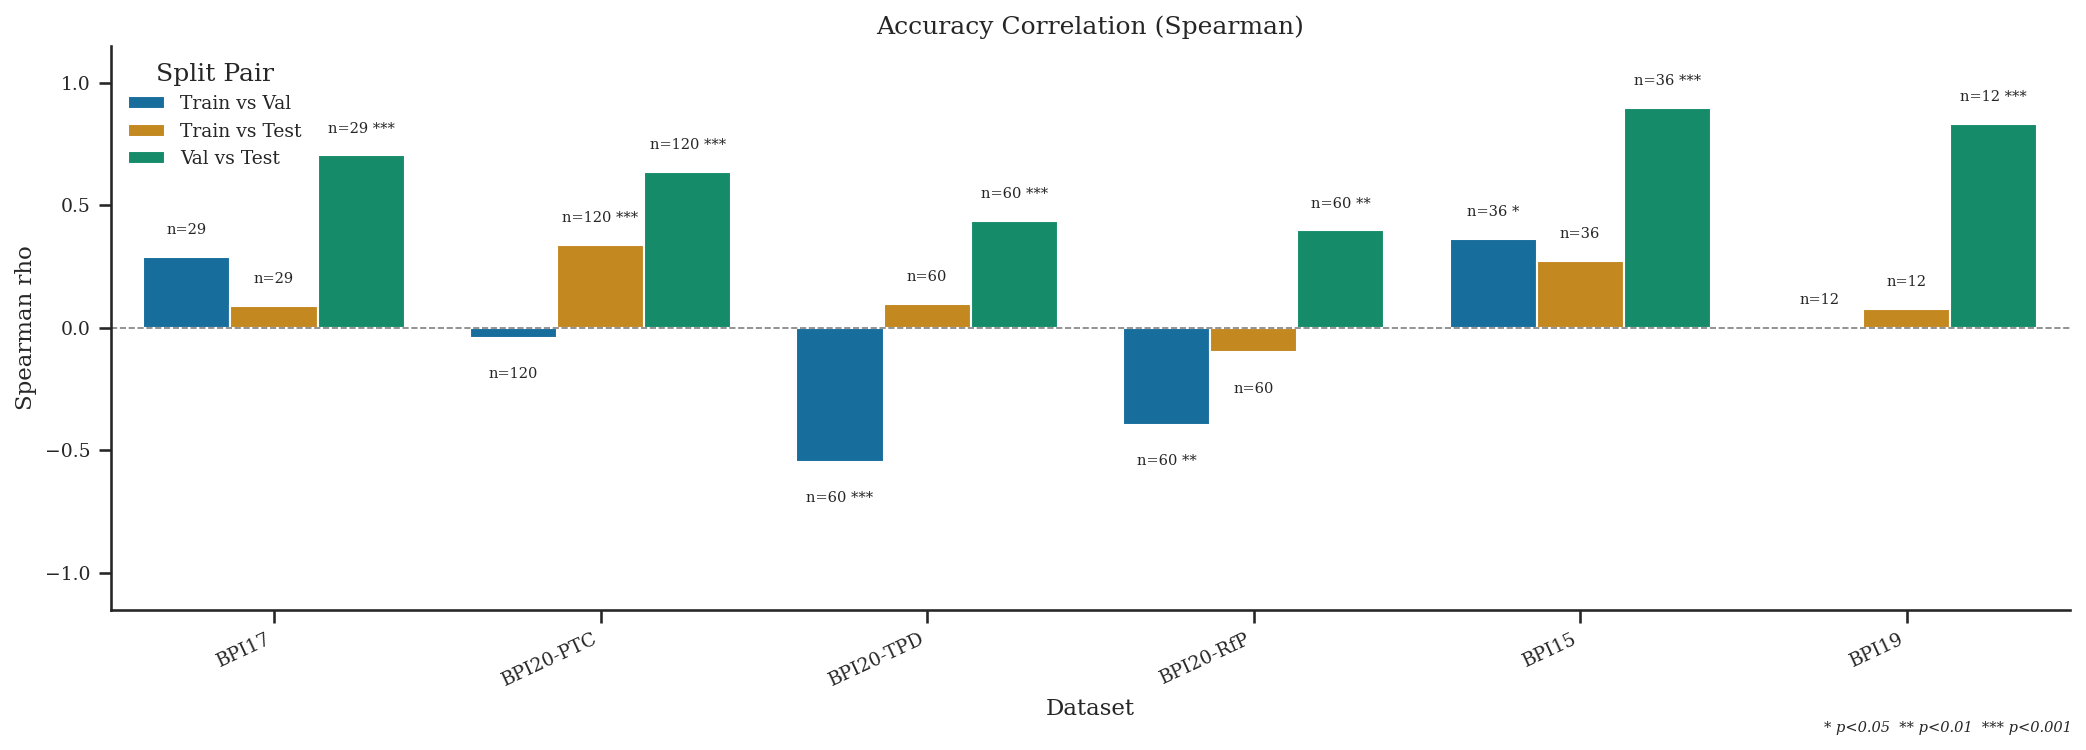

In [13]:
metric_pairs_acc = [
    ("train_next_activity_acc", "val_next_activity_acc"),
    ("train_next_activity_acc", "test_next_activity_acc"),
    ("val_next_activity_acc", "test_next_activity_acc"),
]

fig_acc_pearson = plot_correlation_bars(
    runs,
    group_col="log",
    metric_pairs=metric_pairs_acc,
    method="pearson",
    config=PlotConfig(
        figsize=(14, 5),
        title="Accuracy Correlation (Pearson)",
        ylabel="Pearson r",
        legend_title="Split Pair",
        xtick_rotation=25,
    )
)

fig_acc_spearman = plot_correlation_bars(
    runs,
    group_col="log",
    metric_pairs=metric_pairs_acc,
    method="spearman",
    config=PlotConfig(
        figsize=(14, 5),
        title="Accuracy Correlation (Spearman)",
        ylabel="Spearman rho",
        legend_title="Split Pair",
        xtick_rotation=25,
    )
)

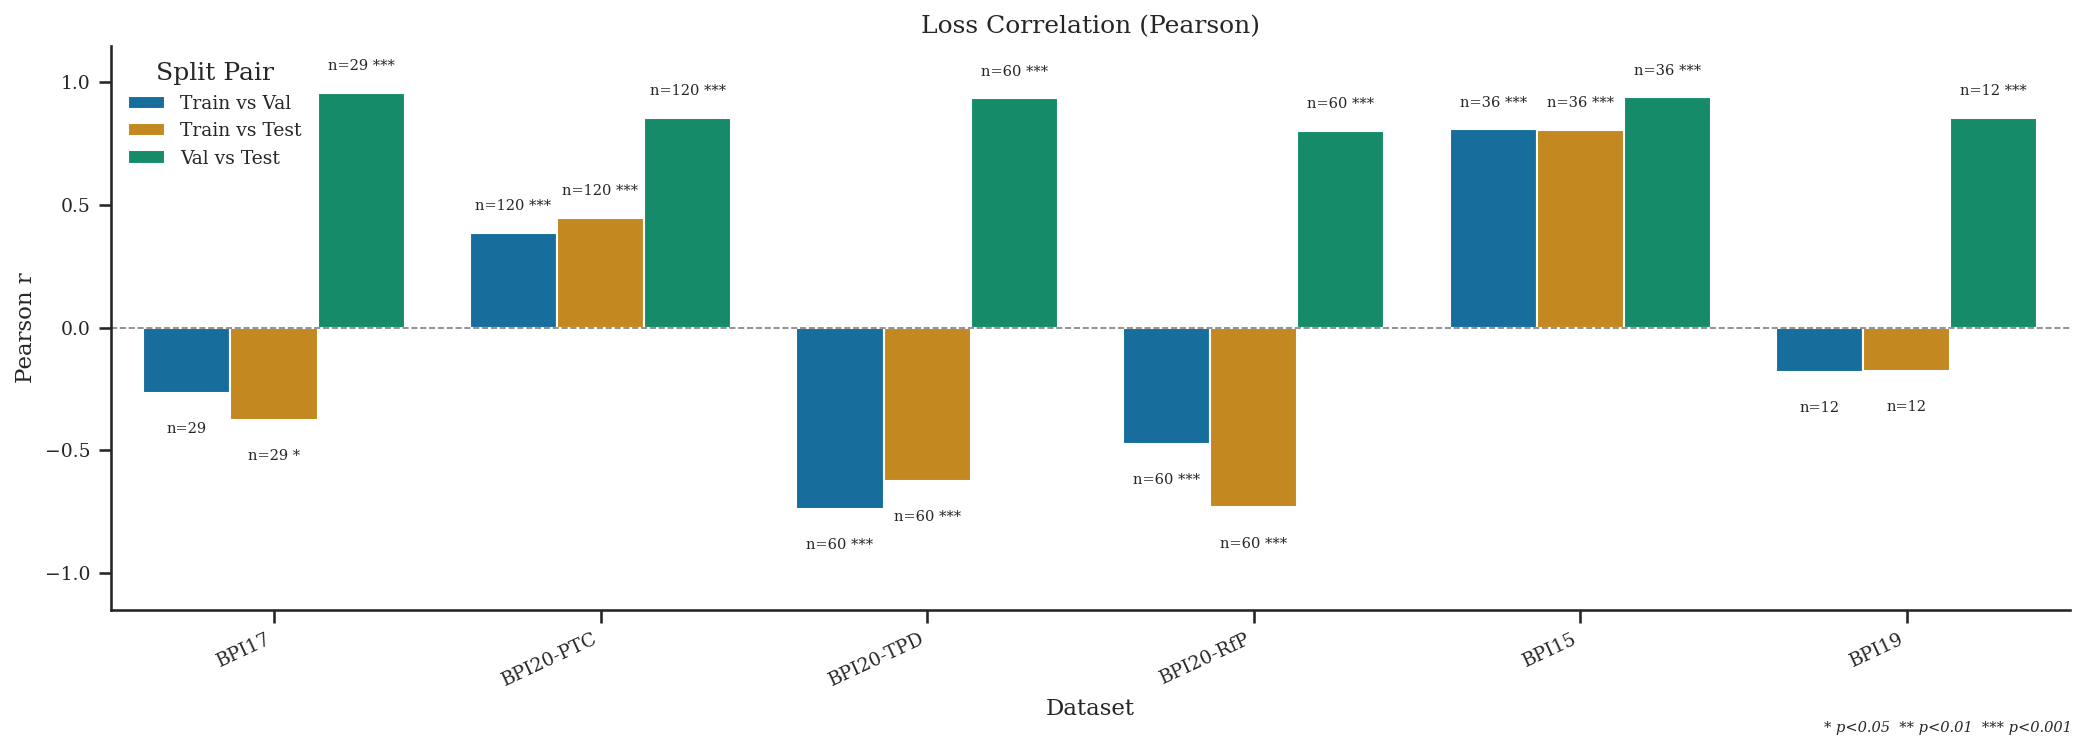

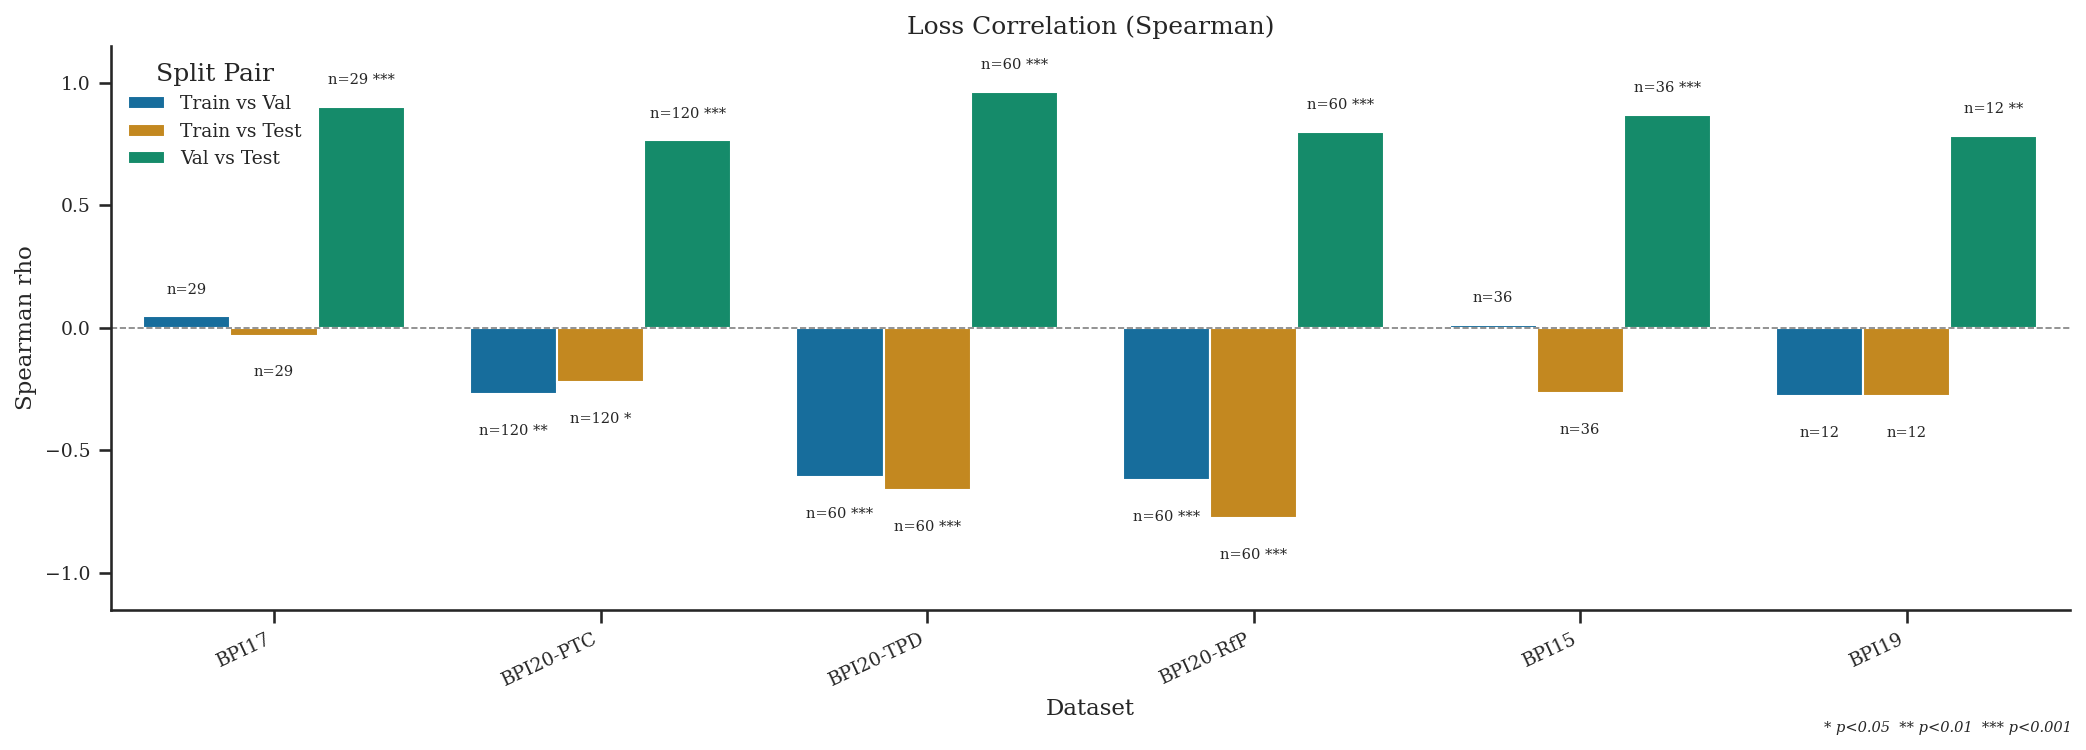

In [14]:
metric_pairs_loss = [
    ("train_next_activity_loss", "val_next_activity_loss"),
    ("train_next_activity_loss", "test_next_activity_loss"),
    ("val_next_activity_loss", "test_next_activity_loss"),
]

fig_loss_pearson = plot_correlation_bars(
    runs,
    group_col="log",
    metric_pairs=metric_pairs_loss,
    method="pearson",
    config=PlotConfig(
        figsize=(14, 5),
        title="Loss Correlation (Pearson)",
        ylabel="Pearson r",
        legend_title="Split Pair",
        xtick_rotation=25,
    )
)

fig_loss_spearman = plot_correlation_bars(
    runs,
    group_col="log",
    metric_pairs=metric_pairs_loss,
    method="spearman",
    config=PlotConfig(
        figsize=(14, 5),
        title="Loss Correlation (Spearman)",
        ylabel="Spearman rho",
        legend_title="Split Pair",
        xtick_rotation=25,
    )
)